# Progetto Data Science — Customer Churn
## Fase 3 — Analisi esplorativa e visualizzazione

In questo notebook verifichiamo alcune delle ipotesi formulate in Fase 2 (`01_setup_e_comprensione_dataset.ipynb`), usando grafici diversi per esplorare le relazioni tra le variabili e il target `Churn`.

Schema seguito per ogni ipotesi: domanda → dato mostrato con un grafico → risposta basata sui dati.


## 1. Import e preparazione dei dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')

df = pd.read_csv('../data/Customer_Churn.csv')

# Stessa pulizia vista in Fase 2: TotalCharges va convertito in numerico,
# i vuoti corrispondono a clienti con tenure = 0 (appena iscritti)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f"Dataset pronto: {df.shape[0]} righe, {df.shape[1]} colonne")


Dataset pronto: 7043 righe, 21 colonne


## 2. Ipotesi 1 — Il tipo di contratto influisce sul churn?

**Domanda:** i clienti con contratto mensile (`Month-to-month`) abbandonano più spesso di chi ha un contratto annuale o biennale?

Confrontiamo il tasso di churn (percentuale di clienti che abbandonano) nei tre gruppi definiti da `Contract`.


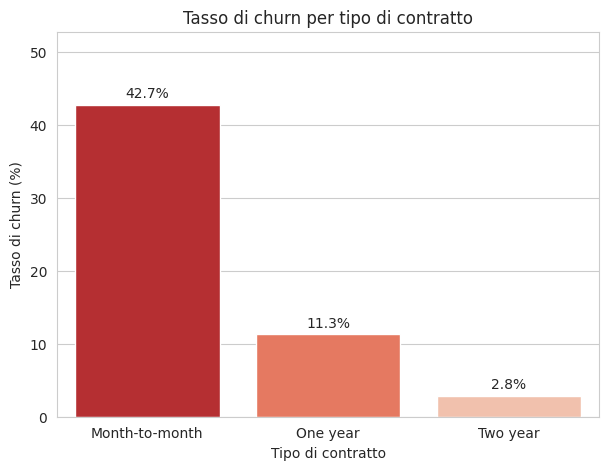

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64

In [2]:
churn_by_contract = (
    df.groupby('Contract')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reindex(['Month-to-month', 'One year', 'Two year'])
)

plt.figure(figsize=(7, 5))
sns.barplot(x=churn_by_contract.index, y=churn_by_contract.values, hue=churn_by_contract.index, palette='Reds_r', legend=False)
plt.ylabel('Tasso di churn (%)')
plt.xlabel('Tipo di contratto')
plt.title('Tasso di churn per tipo di contratto')
for i, v in enumerate(churn_by_contract.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.ylim(0, churn_by_contract.max() + 10)
plt.savefig('../figures/churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

churn_by_contract.round(1)


**Risposta:** l'ipotesi è confermata dai dati. I clienti con contratto mensile abbandonano molto più spesso (oltre il 40%) rispetto a chi ha un contratto annuale (~11%) o biennale (circa il 3%). È il confronto più netto tra tutti quelli analizzati in questo notebook: il tipo di contratto sembra essere il fattore più fortemente associato al churn.

Questo è anche il nostro primo **confronto tra gruppi** richiesto dalla Fase 3.


## 3. Ipotesi 2 — I clienti più recenti abbandonano di più?

**Domanda:** i clienti con `tenure` basso (cioè clienti da poco in azienda) hanno un tasso di churn più alto rispetto ai clienti di lunga data?

Qui confrontiamo una variabile numerica (`tenure`) tra i due gruppi definiti dal target (`Churn = Yes` vs `Churn = No`) — il nostro secondo **confronto tra gruppi/classi**.


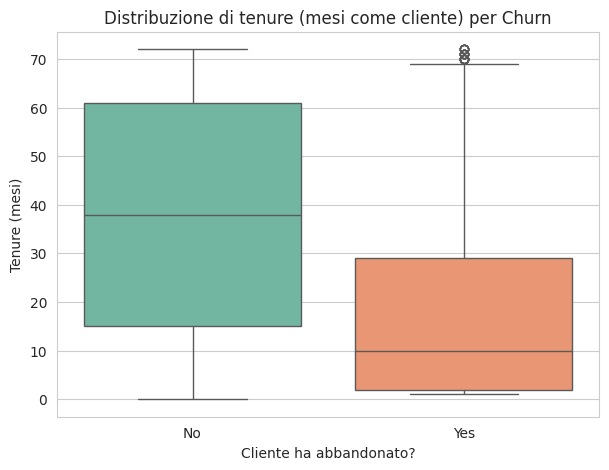

,mean,median,std
Churn,,,
No,37.6,38.0,24.1
Yes,18.0,10.0,19.5


In [3]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn', palette='Set2', legend=False)
plt.title('Distribuzione di tenure (mesi come cliente) per Churn')
plt.xlabel('Cliente ha abbandonato?')
plt.ylabel('Tenure (mesi)')
plt.savefig('../figures/tenure_by_churn.png', dpi=150, bbox_inches='tight')
plt.show()

df.groupby('Churn')['tenure'].agg(['mean', 'median', 'std']).round(1)


**Risposta:** confermata. I clienti che abbandonano hanno una `tenure` mediana molto più bassa (10 mesi) rispetto a chi resta (mediana 38 mesi circa). Il boxplot mostra chiaramente che la distribuzione dei clienti che se ne vanno è concentrata sui valori bassi. Questo è coerente con l'ipotesi 1: chi ha un contratto mensile è anche, plausibilmente, chi è arrivato da meno tempo.


## 4. Ipotesi 7 — Un addebito mensile più alto è associato a più churn?

**Domanda:** i clienti con `MonthlyCharges` più alto abbandonano più spesso?

Usiamo una distribuzione sovrapposta (istogramma con stima di densità) per confrontare la forma della distribuzione di `MonthlyCharges` nei due gruppi.


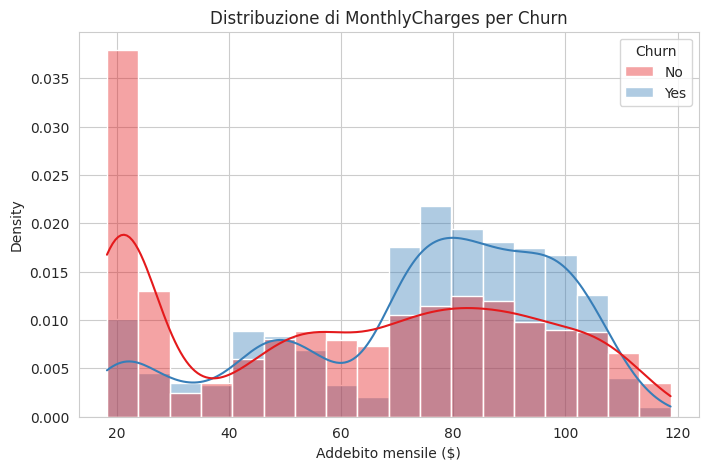

,mean,median
Churn,,
No,61.3,64.4
Yes,74.4,79.6


In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, stat='density', common_norm=False, palette='Set1', alpha=0.4)
plt.title('Distribuzione di MonthlyCharges per Churn')
plt.xlabel('Addebito mensile ($)')
plt.savefig('../figures/monthlycharges_by_churn.png', dpi=150, bbox_inches='tight')
plt.show()

df.groupby('Churn')['MonthlyCharges'].agg(['mean', 'median']).round(1)


**Risposta:** parzialmente confermata. I clienti che abbandonano tendono ad avere addebiti mensili più alti in media (~74$) rispetto a chi resta (~61$), e la distribuzione di chi abbandona è spostata verso destra. Non è una separazione netta come per `tenure` o `Contract`, ma la tendenza è visibile: probabilmente `MonthlyCharges` da solo è un fattore più debole, che si combina con altri (es. tipo di contratto o servizi attivati) per spiegare l'abbandono.


## 5. Ipotesi 3 — Il metodo di pagamento influisce sul churn?

**Domanda:** i clienti che pagano con `Electronic check` abbandonano più spesso rispetto agli altri metodi di pagamento?


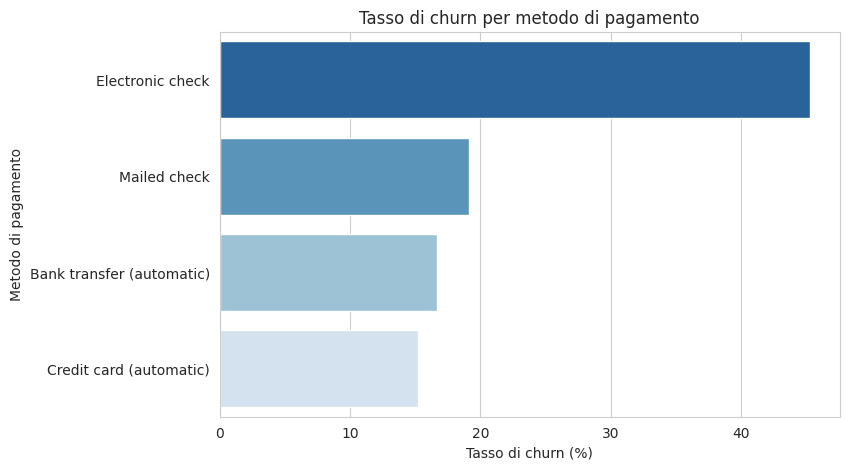

PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Name: Churn, dtype: float64

In [5]:
churn_by_payment = (
    df.groupby('PaymentMethod')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=churn_by_payment.values, y=churn_by_payment.index, hue=churn_by_payment.index, palette='Blues_r', legend=False)
plt.xlabel('Tasso di churn (%)')
plt.ylabel('Metodo di pagamento')
plt.title('Tasso di churn per metodo di pagamento')
plt.savefig('../figures/churn_by_payment.png', dpi=150, bbox_inches='tight')
plt.show()

churn_by_payment.round(1)


**Risposta:** confermata. I clienti che pagano con `Electronic check` hanno un tasso di churn (~45%) molto più alto degli altri tre metodi, che sono tutti sotto il 20%. È un risultato che vale la pena approfondire in Fase 5: potrebbe essere legato al fatto che chi sceglie questo metodo di pagamento è spesso anche chi ha un contratto mensile (nessun vincolo di pagamento automatico ricorrente).


## 6. Le variabili numeriche sono ridondanti tra loro?

Non è legata a una singola ipotesi dell'elenco, ma è un controllo utile prima della modellazione (Fase 4): verifichiamo se `tenure`, `MonthlyCharges` e `TotalCharges` sono fortemente correlate tra loro, cosa che avevamo ipotizzato come possibile problema nella riflessione critica della Fase 2.


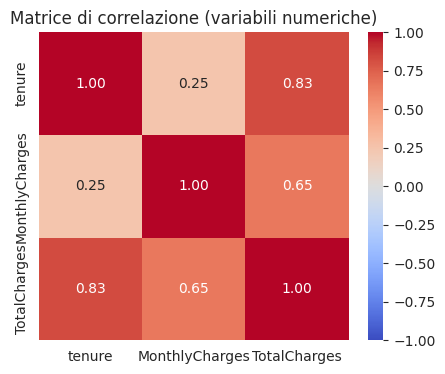

In [6]:
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Matrice di correlazione (variabili numeriche)')
plt.savefig('../figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretazione:** `TotalCharges` è fortemente correlata sia con `tenure` (0.83) sia con `MonthlyCharges` (0.65) — il che ha senso, perché `TotalCharges` è in buona parte il prodotto delle altre due (più a lungo un cliente resta e più paga al mese, più alto sarà il totale fatturato). Questa è una vera collinearità: andrà tenuta presente in Fase 4, valutando se includere tutte e tre le variabili in un modello lineare come la regressione logistica, dove la collinearità può rendere instabili i coefficienti.


## 7. Riepilogo Fase 3

| # | Ipotesi | Grafico | Esito |
|---|---|---|---|
| 1 | Contratto mensile → più churn | Barplot | Confermata, effetto molto forte |
| 2 | Tenure bassa → più churn | Boxplot | Confermata |
| 3 | Electronic check → più churn | Barplot | Confermata |
| 7 | MonthlyCharges alto → più churn | Istogramma/KDE | Parzialmente confermata, effetto più debole |
| — | Collinearità tra variabili numeriche | Heatmap | Presente tra TotalCharges e le altre due |

Requisiti Fase 3 soddisfatti: 5 grafici diversi (barplot ×2, boxplot, istogramma/KDE, heatmap), 4 ipotesi verificate, 2 confronti espliciti tra gruppi/classi (Contract, Churn).

Prossimo passo (Fase 4): modellazione, usando almeno 3 modelli diversi (almeno uno lineare, es. regressione logistica, e uno non lineare, es. Random Forest), tenendo conto di quanto scoperto qui — in particolare la collinearità tra le variabili numeriche e la forte associazione con `Contract` e `PaymentMethod`.
